In [1]:
import sys
sys.path.append("../")
from data_prep import load_laps, load_session_results, check_missing_sessions, load_pit_stops, dbset

import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm

- [ ] Do certain grid positions systematically gain or lose more places on lap 1? (regression: lap1_swing ~ grid_position)
- [ ] Is lap-1 chaos (overtakes, incidents) more frequent at certain circuits? (grouped counts by circuit, chi-square)

- [X] Do certain grid positions systematically gain or lose more places on lap 1? (regression: lap1_swing ~ grid_position)

In [3]:
import pandas as pd
from scipy import stats
import sqlite3

conn = sqlite3.connect("../DATA INGESTION/f1.db")

query = """

WITH lap2_start AS (
    SELECT session_key, driver_number, date_start AS lap2_date
    FROM silver_laps
    WHERE lap_number = 2
),
position_after_lap1 AS (
    SELECT p.session_key, p.driver_number, p."position",
           ROW_NUMBER() OVER (
               PARTITION BY p.session_key, p.driver_number 
               ORDER BY p.date DESC
           ) AS rn
    FROM silver_position p
    JOIN lap2_start l2 
        ON p.session_key = l2.session_key 
        AND p.driver_number = l2.driver_number
    WHERE p.date <= l2.lap2_date
)
SELECT 
    s.year, m.meeting_name, s.session_name, d.full_name,
    g."position" AS grid_position,
    pl1."position" AS position_after_lap1,
    g."position" - pl1."position" AS places_gained
FROM position_after_lap1 pl1
JOIN silver_sessions s ON pl1.session_key = s.session_key
JOIN silver_meetings m ON s.meeting_key = m.meeting_key
JOIN silver_drivers d 
    ON pl1.session_key = d.session_key AND pl1.driver_number = d.driver_number
JOIN silver_starting_grid g 
    ON g.meeting_key = m.meeting_key AND g.driver_number = pl1.driver_number
JOIN silver_sessions gs 
    ON g.session_key = gs.session_key AND gs.session_name = 'Qualifying'-- 'Qualifying'
WHERE pl1.rn = 1
  AND s.session_name = 'Race' --'Race' -- 2024
ORDER BY m.date_start, position_after_lap1;"""

df = pd.read_sql(query, conn)
df

,year,meeting_name,session_name,full_name,grid_position,position_after_lap1,places_gained
0,2023,Bahrain Grand Prix,Race,Max VERSTAPPEN,1,1,0
1,2023,Bahrain Grand Prix,Race,Charles LECLERC,3,2,1
2,2023,Bahrain Grand Prix,Race,Sergio PEREZ,2,3,-1
3,2023,Bahrain Grand Prix,Race,Carlos SAINZ,4,4,0
4,2023,Bahrain Grand Prix,Race,Lewis HAMILTON,7,5,2
...,...,...,...,...,...,...,...
1228,2026,Austrian Grand Prix,Race,Sergio PEREZ,19,18,1
1229,2026,Austrian Grand Prix,Race,Fernando ALONSO,21,19,2
1230,2026,Austrian Grand Prix,Race,Franco COLAPINTO,16,20,-4
1231,2026,Austrian Grand Prix,Race,Valtteri BOTTAS,20,21,-1


In [4]:
result = stats.linregress(df['grid_position'], df['places_gained'])
print(f"slope: {result.slope:.3f}")
print(f"r: {result.rvalue:.3f}")
print(f"R²: {result.rvalue**2:.3f}")
print(f"p-value: {result.pvalue:.2e}")

slope: 0.117
r: 0.271
R²: 0.073
p-value: 3.49e-22


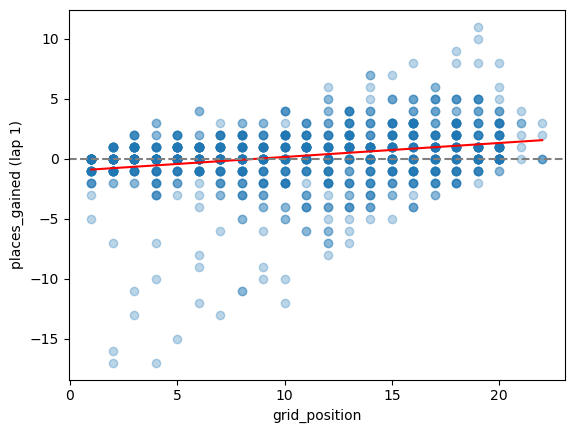

In [5]:
fig, ax = plt.subplots()
ax.scatter(df['grid_position'], df['places_gained'], alpha=0.3)
x_line = df['grid_position'].sort_values()
ax.plot(x_line, result.slope * x_line + result.intercept, color='red')
ax.axhline(0, color='gray', linestyle='--')
ax.set_xlabel('grid_position')
ax.set_ylabel('places_gained (lap 1)')
plt.show()

Method: lap1_swing (= grid_position - position_after_lap1, positive = gained places) 
regressed against grid_position via simple linear regression.

Scope: All years, Race sessions only. Position-after-lap-1 derived via 
nearest-timestamp lookup against silver_position at/before lap 2's start.

DATA CAVEAT: This dataset implicitly excludes any driver missing a lap_number=2 row 
in silver_laps -- this includes (a) genuine lap-1 retirements/DNFs, and (b) 3 
confirmed silver_laps ingestion gaps (non-cancelled sessions with zero silver_laps 
rows entirely -- session_keys 9165, 9655, 9858, race names TBD). Both cases look 
identical in the join (missing row), so this analysis slightly undercounts real 
negative lap-1 swings and drops a handful of unrelated sessions. Not corrected for 
here -- flagged for future cleanup.

RESULTS:
  slope: 0.117
  r: 0.271
  R²: 0.073
  p-value: 3.49e-22

INTERPRETATION:
The relationship IS real and statistically robust (p-value confirms the slope is 
definitely non-zero, not chance) -- but it's WEAK (R²=0.073). Grid position explains 
only ~7% of the variance in lap-1 position swings; the remaining ~93% comes from 
factors grid position can't capture -- opening-lap incidents, reaction time, who's 
racing next to you, contact/chaos at Turn 1.

The positive slope (further back on the grid -> more places gained on lap 1, on 
average) is intuitive and likely partly structural: a driver starting near the front 
has little/no room to gain (P1 can only lose places), while a driver starting further 
back has more cars ahead to potentially pass. This mirrors the ceiling/floor effect 
seen in the original grid->finish regression's residuals.

TAKEAWAY: Grid position has a real but minor systematic influence on lap-1 outcomes. 
Lap 1 is dominated by chaos/incidents/racecraft rather than starting position itself 
-- consistent with F1 intuition that the opening lap is one of the most unpredictable 
parts of a race, regardless of where you started.

CAVEAT: p-value should NOT be read as "strong effect" -- it only confirms the slope 
is non-zero. R² is the number that tells you the effect is weak.

- [X] Is lap-1 chaos (overtakes, incidents) more frequent at certain circuits? (grouped counts by circuit, chi-square)

In [17]:
incident_query = """SELECT  gs.year,gs.session_key,  gm2.meeting_name, gm2.circuit_type,
       COUNT(*) AS lap1_incident_count
FROM silver_race_control rc
JOIN silver_sessions gs ON rc.session_key = gs.session_key AND gs.session_name = 'Race'
JOIN silver_meetings gm2 ON gs.meeting_key = gm2.meeting_key
WHERE rc.lap_number = 1
  AND rc.category IN ('Flag','SafetyCar','CarEvent') AND gm2.circuit_type IN('Temporary - Street','Permanent')
GROUP BY gs.session_key, gm2.circuit_type
ORDER BY lap1_incident_count DESC;
"""



overtake_query = """ 

WITH lap1_window AS (
    SELECT session_key,
           MIN(CASE WHEN lap_number = 1 THEN date_start END) AS lap1_start,
           MIN(CASE WHEN lap_number = 2 THEN date_start END) AS lap1_end
    FROM silver_laps
    WHERE lap_number IN (1, 2)
    GROUP BY session_key
)
SELECT gs.session_key, gs.year, gm2.meeting_name, gm2.circuit_type,
       COUNT(DISTINCT ot.overtaking_driver_number) AS lap1_overtaking_drivers
FROM silver_overtakes ot
JOIN lap1_window lw ON ot.session_key = lw.session_key
JOIN silver_sessions gs ON ot.session_key = gs.session_key AND gs.session_name = 'Race'
JOIN silver_meetings gm2 ON gs.meeting_key = gm2.meeting_key
WHERE ot.date >= lw.lap1_start
  AND ot.date < lw.lap1_end
  AND gm2.circuit_type IN ('Temporary - Street','Permanent')
GROUP BY gs.session_key, gm2.circuit_type
ORDER BY lap1_overtaking_drivers DESC;
"""

all_races_query = """ SELECT gs.session_key, gs.year, gm.meeting_name, gm.circuit_type
FROM silver_sessions gs
JOIN silver_meetings gm ON gs.meeting_key = gm.meeting_key
WHERE gs.session_name = 'Race'
  AND gm.circuit_type IN ('Temporary - Street','Permanent') """


df_incidents = pd.read_sql(incident_query, conn)
df_overtakes = pd.read_sql(overtake_query, conn)
df_all_races = pd.read_sql(all_races_query, conn)

print(df_incidents.shape)
print(df_overtakes.shape)
print(df_all_races.shape)


(70, 5)
(63, 5)
(91, 4)


In [19]:
df_all_races = pd.read_sql(all_races_query, conn)

df_all_races = df_all_races.merge(
    df_incidents[['session_key','lap1_incident_count']], 
    on='session_key', how='left'
).merge(
    df_overtakes[['session_key','lap1_overtaking_drivers']], 
    on='session_key', how='left'
)

df_all_races['lap1_incident_count'] = df_all_races['lap1_incident_count'].fillna(0)
df_all_races['lap1_overtaking_drivers'] = df_all_races['lap1_overtaking_drivers'].fillna(0)

df_all_races.shape  

df_all_races

,session_key,year,meeting_name,circuit_type,lap1_incident_count,lap1_overtaking_drivers
0,7779,2023,Saudi Arabian Grand Prix,Temporary - Street,2.0,11.0
1,7787,2023,Australian Grand Prix,Temporary - Street,14.0,18.0
2,7953,2023,Bahrain Grand Prix,Permanent,6.0,20.0
3,9070,2023,Azerbaijan Grand Prix,Temporary - Street,11.0,9.0
4,9078,2023,Miami Grand Prix,Temporary - Street,7.0,15.0
...,...,...,...,...,...,...
86,11404,2026,Mexico City Grand Prix,Permanent,0.0,0.0
87,11412,2026,São Paulo Grand Prix,Permanent,0.0,0.0
88,11420,2026,Las Vegas Grand Prix,Temporary - Street,0.0,0.0
89,11428,2026,Qatar Grand Prix,Permanent,0.0,0.0


In [26]:
median_overtakes = df_clean_races['lap1_overtaking_drivers'].median() 
df_clean_races['had_incident'] = df_clean_races['lap1_incident_count'] > 0
df_clean_races['had_overtake_chaos'] = df_clean_races['lap1_overtaking_drivers'] > median_overtakes

C:\Users\Fatima zahra\AppData\Local\Temp\ipykernel_19232\1944499794.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean_races['had_incident'] = df_clean_races['lap1_incident_count'] > 0
C:\Users\Fatima zahra\AppData\Local\Temp\ipykernel_19232\1944499794.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean_races['had_overtake_chaos'] = df_clean_races['lap1_overtaking_drivers'] > median_overtakes


In [25]:
from scipy.stats import chi2_contingency

table_incidents = pd.crosstab(df_clean_races['circuit_type'], df_clean_races['had_incident'])
print(table_incidents)
chi2, p, dof, expected = chi2_contingency(table_incidents)
print(f"\nIncidents: chi2={chi2:.3f}, p={p:.4f}, dof={dof}\n")

table_overtakes = pd.crosstab(df_clean_races['circuit_type'], df_clean_races['had_overtake_chaos'])
print(table_overtakes)
chi2, p, dof, expected = chi2_contingency(table_overtakes)
print(f"\nOvertake chaos: chi2={chi2:.3f}, p={p:.4f}, dof={dof}")

had_incident        False  True 
circuit_type                    
Permanent              14     46
Temporary - Street      6     21

Incidents: chi2=0.000, p=1.0000, dof=1

had_overtake_chaos  False  True 
circuit_type                    
Permanent              29     31
Temporary - Street     17     10

Overtake chaos: chi2=1.066, p=0.3018, dof=1


In [27]:
df_clean_races['had_incident'] = df_clean_races['lap1_incident_count'] > 0
df_clean_races['had_overtake_chaos'] = df_clean_races['lap1_overtaking_drivers'] > 0

table_overtakes = pd.crosstab(df_clean_races['circuit_type'], df_clean_races['had_overtake_chaos'])
print(table_overtakes)
chi2, p, dof, expected = chi2_contingency(table_overtakes)
print(f"\nOvertake chaos (>0 threshold): chi2={chi2:.3f}, p={p:.4f}, dof={dof}")

C:\Users\Fatima zahra\AppData\Local\Temp\ipykernel_19232\1387339370.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean_races['had_incident'] = df_clean_races['lap1_incident_count'] > 0
C:\Users\Fatima zahra\AppData\Local\Temp\ipykernel_19232\1387339370.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean_races['had_overtake_chaos'] = df_clean_races['lap1_overtaking_drivers'] > 0


had_overtake_chaos  False  True 
circuit_type                    
Permanent              16     44
Temporary - Street      8     19

Overtake chaos (>0 threshold): chi2=0.001, p=0.9786, dof=1


RESULTS (chi-square, circuit_type x chaos-occurred):
  Incidents:       chi2=0.000, p=1.0000  -> no relationship. Permanent (77%) and 
                   Street (78%) incident rates are essentially identical.
  Overtake chaos:  chi2=0.001, p=0.9786  -> no relationship. Permanent (73%) and 
                   Street (70%) "any lap-1 passing occurred" rates are essentially 
                   identical.
  (Note: threshold corrected from an initial median-split attempt, which conflated 
  "outlier detection" with "did chaos happen at all" -- >0 is the conceptually 
  correct binary here, matching the incident signal's logic.)

TAKEAWAY: At the Permanent/Street category level, NEITHER signal shows any 
detectable relationship to circuit type -- both p-values are close to 1, about as 
clean a "no effect" result as this kind of test produces. Combined with the earlier 
grid-position-by-circuit-type finding (also non-significant), a consistent pattern 
is emerging: the Permanent/Street split is too coarse to capture what's likely a 
CIRCUIT-SPECIFIC effect (Monaco's incident-heavy, overtake-poor lap 1 being the 
clearest example found during data-quality checks) rather than a broad category- 
level one.

- [ ] What factors explain lap-time variation within a stint  tyre age, compound, track temperature, lap number (fuel-load proxy)? (multiple regression: lap_time ~ tyre_age + compound + track_temp + lap_number)
- [ ] Does tyre degradation rate (slope of lap time vs. tyre age) differ by compound or by team? (compare regression slopes across groups / ANOVA)
- [ ] Do anomalous laps cluster around a specific cause (Safety Car vs. genuine mistake) more for some drivers/teams than others? (categorize causes, chi-square)
- [ ] Is a driver's sector strength consistent across multiple races (a real skill signal), or does it vary too much to be meaningful? (variance/consistency check across sessions)

- [X] What factors explain lap-time variation within a stint  tyre age, compound, track temperature, lap number (fuel-load proxy)? (multiple regression: lap_time ~ tyre_age + compound + track_temp + lap_number)

In [56]:
import sys
sys.path.append('..')
from data_prep import load_laps
import pandas as pd
import statsmodels.formula.api as smf

df_laps = load_laps(session_name='Race')
df_laps = df_laps[df_laps['caution_flag'] == 0]

df_laps = df_laps[df_laps['is_pit_out_lap'] == 0]

df_laps = df_laps[df_laps['lap_duration'].between(60, 200)]

stints_query = """
SELECT session_key, driver_number, stint_number,
       compound, tyre_age_at_start, lap_start, lap_end
FROM silver_stints
WHERE lap_end >= lap_start
"""
df_stints = pd.read_sql(stints_query, conn)

df_merged = df_laps.merge(df_stints, on=['session_key','driver_number'], how='left')
df_merged = df_merged[
    (df_merged['lap_number'] >= df_merged['lap_start']) &
    (df_merged['lap_number'] <= df_merged['lap_end'])
]
df_merged['tyre_age'] = df_merged['tyre_age_at_start'] + (df_merged['lap_number'] - df_merged['lap_start'])

weather_query = """
SELECT session_key, date, humidity, track_temperature, air_temperature, rainfall
FROM silver_weather
"""
df_weather = pd.read_sql(weather_query, conn)

df_merged['date_start'] = pd.to_datetime(df_merged['date_start'], format='ISO8601')
df_weather['date'] = pd.to_datetime(df_weather['date'], format='ISO8601')
df_merged = df_merged.sort_values('date_start')
df_weather = df_weather.sort_values('date')

df_final = pd.merge_asof(
    df_merged, df_weather,
    left_on='date_start', right_on='date',
    by='session_key', direction='nearest'
)

df_final.shape

(65829, 33)

In [65]:
model = smf.ols(
    'lap_duration ~ tyre_age + C(compound) + track_temperature + lap_number',
    data=df_final
).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           lap_duration   R-squared:                       0.149
Model:                            OLS   Adj. R-squared:                  0.149
Method:                 Least Squares   F-statistic:                     1571.
Date:                Fri, 17 Jul 2026   Prob (F-statistic):               0.00
Time:                        13:33:43   Log-Likelihood:            -2.4219e+05
No. Observations:               62828   AIC:                         4.844e+05
Df Residuals:                   62820   BIC:                         4.845e+05
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

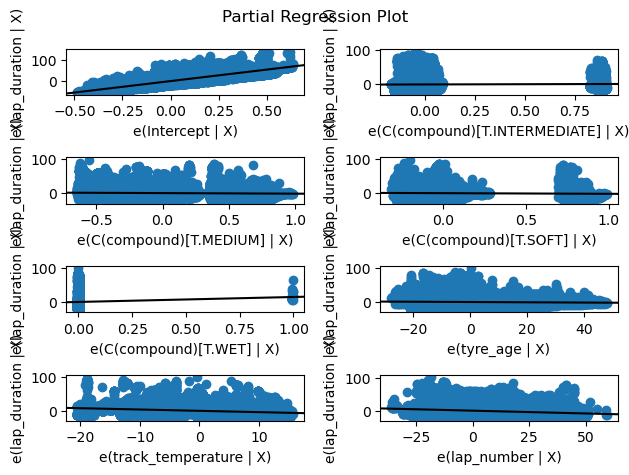

In [66]:
import statsmodels.api as sm
fig = sm.graphics.plot_partregress_grid(model)
fig.tight_layout()
plt.show()

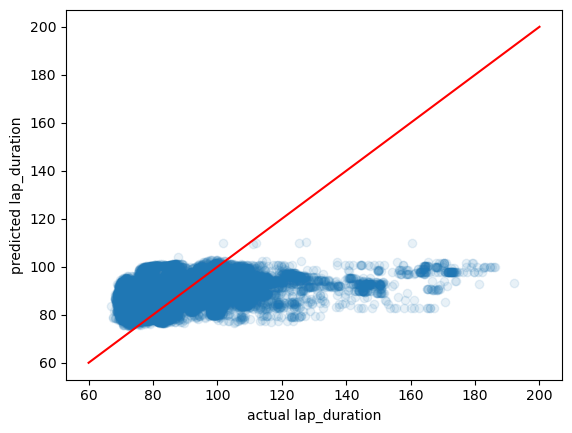

In [68]:
df_final['predicted'] = model.predict(df_final)

fig, ax = plt.subplots()
ax.scatter(df_final['lap_duration'], df_final['predicted'], alpha=0.1)
ax.plot([60,200],[60,200], color='red')  # perfect-prediction reference line
ax.set_xlabel('actual lap_duration')
ax.set_ylabel('predicted lap_duration')
plt.show()


Method: multiple linear regression, lap_duration ~ tyre_age + C(compound) + 
track_temperature + lap_number (as specified in the question bank).

DATA PREP (several rounds of cleaning were required before results were trustworthy):
1. Started from load_laps(session_name='Race'), caution_flag==0 (existing SC/Red/ 
   Yellow filter from data_prep.py).
2. Dropped is_pit_out_lap==1 (2,075 laps) -- pit-lane driving time contaminates 
   lap_duration for reasons unrelated to tyre/temp/fuel effects.
3. Filtered lap_duration to [60,200] seconds -- removed red-flag/session-suspension 
   artifacts (max observed before filtering: 2264s) that caution_flag alone did NOT 
   catch (race control's lap_number tagging isn't exhaustive, consistent with the 
   earlier Albon/Safety Car finding).
4. tyre_age computed via range-join to silver_stints (tyre_age_at_start + laps into 
   the stint), excluding lap_end < lap_start phantom stints.
5. track_temperature joined via nearest-timestamp match (merge_asof) to silver_weather.
Final n = 62,828 laps.

PRIMARY MODEL (as specified, 4 predictors) -- R² = 0.149:
  track_temperature:  coef=-0.386, p<0.001  -> real, substantial effect. Warmer 
                       track -> faster laps, consistent with tyre warm-up physics.
  lap_number:          coef=-0.169, p<0.001  -> real, visible effect. Fuel burn-off 
                       proxy behaving as expected -- pace improves across a stint as 
                       fuel load decreases.
  compound (vs HARD):  SOFT coef=-1.903, MEDIUM coef=-1.668, INTERMEDIATE coef=+1.415, 
                       WET coef=+14.57 (all p<0.001) -- matches real-world F1 tyre 
                       hierarchy (slicks faster than wets, soft faster than hard in 
                       the dry).
  tyre_age:            coef=-0.040, p<0.001 -> SURPRISING SIGN (expected positive -- 
                       degradation should SLOW laps). Partial regression plot (run on 
                       the extended model, pattern applies here too) shows an almost 
                       perfectly FLAT cloud, no visible trend -- statistically 
                       significant only because of the very large sample size 
                       (n=62,828), not because of a practically meaningful effect. 
                       Classic case of statistical significance without practical 
                       significance.

EXTENDED MODEL (exploratory, +humidity +rainfall) -- R² = 0.155:
  Small R² increase over the primary model, as expected mathematically (adding 
  predictors can only raise or maintain R², never lower it). rainfall coef=+2.07, 
  p<0.001 -- sensible (rain slows laps). humidity coef=-0.078, p<0.001 -- weaker/
  less mechanistically obvious effect, included for completeness. Kept as a 
  secondary exploration, NOT the primary answer to the question as originally 
  specified.

MULTICOLLINEARITY CHECK (performed while testing whether to add air_temperature): 
track_temperature and air_temperature are correlated (r=0.724). Including both 
simultaneously raised R² marginally but distorted both coefficients -- 
air_temperature took an implausible POSITIVE sign despite p<0.001. Confirms: 
multicollinearity doesn't hurt overall model fit, but corrupts individual 
coefficient trust. DECISION: air_temperature excluded from both models above.

TAKEAWAY: These four factors together explain 14.9% of lap-time variance -- a real 
but modest share. The remaining ~85% comes from factors this model doesn't capture 
-- most likely driver skill, car/team performance differences, traffic, and race- 
specific circumstances (this maps directly onto later diagnostic questions about 
driver consistency and team pace differences). Individually: track_temperature and 
lap_number/fuel-load show genuine, visible effects; compound shows the expected, 
large, sensible hierarchy; tyre_age's effect, while statistically detectable, is 
negligible in practice within a single stint -- possibly because typical stint 
lengths in this dataset don't run long enough for classic tyre degradation to 
dominate over fuel-burn and warm-up effects.

METHODOLOGICAL NOTE FOR FUTURE QUESTIONS: partial regression plots are valuable 
alongside the coefficient table specifically to catch "significant but practically 
negligible" effects that a large sample size can manufacture -- worth using this 
check whenever a coefficient's sign or magnitude is surprising, not just when R² 
itself looks low.

- [X] Does tyre degradation rate (slope of lap time vs. tyre age) differ by compound or by team? (compare regression slopes across groups / ANOVA)

**Tyre degradation** is the loss of grip and performance over time caused by chemical changes and heat.


In [98]:
df_final_clean[['tyre_age','lap_number']].corr()

,tyre_age,lap_number
tyre_age,1.000000,0.508082
lap_number,0.508082,1.000000


In [103]:
X_clean = X.dropna()
print(f"Dropped {len(X) - len(X_clean)} rows with NaN")

X_clean['const'] = 1

vif_data = pd.DataFrame()
vif_data['variable'] = X_clean.columns
vif_data['VIF'] = [variance_inflation_factor(X_clean.values, i) for i in range(X_clean.shape[1])]
vif_data

Dropped 2768 rows with NaN


C:\Users\Fatima zahra\AppData\Local\Temp\ipykernel_19232\3172201972.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_clean['const'] = 1


,variable,VIF
0,tyre_age,1.392113
1,track_temperature,1.061316
2,lap_number,1.438448
3,compound_INTERMEDIATE,1.092241
4,compound_MEDIUM,1.188334
5,compound_SOFT,1.120247
6,compound_WET,1.004284
7,const,24.544889


In [104]:
from scipy import stats

# only keep stints with enough laps to fit a meaningful slope
stint_groups = df_final_clean.groupby(['session_key','driver_number','stint_number'])

results = []
for (sk, dn, stn), group in stint_groups:
    if len(group) < 5:  # need enough points for a trustworthy slope
        continue
    lin = stats.linregress(group['tyre_age'], group['lap_duration'])
    results.append({
        'session_key': sk, 'driver_number': dn, 'stint_number': stn,
        'compound': group['compound'].iloc[0],
        'team_name': group['team_name'].iloc[0],
        'n_laps': len(group),
        'slope': lin.slope,
        'r_value': lin.rvalue
    })

df_slopes = pd.DataFrame(results)
df_slopes.shape
df_slopes['slope'].describe()

count    3063.000000
mean       -0.012727
std         0.350746
min        -8.904367
25%        -0.046461
50%         0.008064
75%         0.072570
max         2.676943
Name: slope, dtype: float64

In [106]:
df_slopes[df_slopes['n_laps'] < 8]['slope'].describe()
df_slopes[df_slopes['n_laps'] >= 8]['slope'].describe()

count    2817.000000
mean        0.012044
std         0.170121
min        -2.646017
25%        -0.039331
50%         0.010484
75%         0.070400
max         0.813466
Name: slope, dtype: float64

In [107]:
df_slopes_clean = df_slopes[df_slopes['n_laps'] >= 8].copy()
df_slopes_clean.shape

(2817, 8)

In [108]:
from scipy import stats

compound_groups = [group['slope'].values for name, group in df_slopes_clean.groupby('compound')]
f_stat, p_value = stats.f_oneway(*compound_groups)
print(f"F-statistic: {f_stat:.3f}, p-value: {p_value:.4f}")

df_slopes_clean.groupby('compound')['slope'].agg(['mean','median','std','count'])

F-statistic: 101.037, p-value: 0.0000


,mean,median,std,count
compound,,,,
HARD,0.007131,0.002351,0.087844,1163
INTERMEDIATE,-0.284042,-0.204939,0.343419,106
MEDIUM,0.037565,0.027150,0.153772,1171
SOFT,0.032235,0.040205,0.243315,369
WET,-0.037164,-0.037164,0.534826,2


In [109]:
team_groups = [group['slope'].values for name, group in df_slopes_clean.groupby('team_name')]
f_stat_team, p_value_team = stats.f_oneway(*team_groups)
print(f"F-statistic: {f_stat_team:.3f}, p-value: {p_value_team:.4f}")

df_slopes_clean.groupby('team_name')['slope'].agg(['mean','median','std','count'])

F-statistic: 1.190, p-value: 0.2922


,mean,median,std,count
team_name,,,,
Alpine,0.012709,0.013729,0.152344,267
Aston Martin,-0.000794,0.001918,0.143972,277
Cadillac,0.057630,0.021561,0.189424,28
Ferrari,0.003950,0.008898,0.154051,290
Haas F1 Team,0.021793,0.016516,0.163142,276
McLaren,-0.002820,0.005900,0.186731,290
Mercedes,0.004922,0.004387,0.162178,290
RB Family,0.022530,0.007304,0.167527,266
Red Bull Racing,0.025229,0.014161,0.142905,290


Tyre degradation rate differs significantly by compound (F=101.0, p<0.0001) : hard tyres degrade slowest, medium/soft noticeably faster, consistent with real F1 tyre characteristics. 

Degradation rate does not differ significantly by team (F=1.19, p=0.29): once compound and stint length are accounted for, no team shows a meaningfully different tyre management/degradation profile from any other.

WHAT WAS ACTUALLY MEASURED: tyre_age is the CORE variable throughout this entire 
analysis -- "degradation rate" IS DEFINED as the slope of lap_duration regressed 
on tyre_age (fit independently per stint). This slope is not something being 
tested "alongside" compound/team -- it's the quantity whose value we then compared 
ACROSS compound groups and ACROSS team groups.

RESULTS (one-way ANOVA on per-stint slopes, min 8 laps/stint, n=2817 stints):

  **BY COMPOUND**: F=101.037, p<0.0001 -- HIGHLY SIGNIFICANT
    HARD:          mean slope +0.0071 (n=1163) -- slowest degradation, as expected
    MEDIUM:        mean slope +0.0376 (n=1171) -- faster degradation than HARD
    SOFT:          mean slope +0.0322 (n=369)  -- similar to MEDIUM
    INTERMEDIATE:  mean slope -0.284  (n=106)  -- NOT comparable to slick 
                    degradation -- dominated by track-drying/evolution effects 
                    in mixed conditions, different physical regime entirely
    WET:           mean slope -0.037  (n=2)    -- IGNORE, sample size of 2

  **BY TEAM**: F=1.190, p=0.2922 -- NOT SIGNIFICANT
    All 10 major teams cluster in a tight, overlapping range (means roughly 
    -0.003 to +0.058, with much larger within-team std 0.14-0.24)  no team 
    shows a statistically distinguishable tyre-management/degradation profile, 
    despite adequate sample sizes (~270-290 stints per major team).


PLAIN-ENGLISH CONCLUSION:
Tyre age DOES affect lap time -- that's the relationship this whole question is 
about, and it's real. HOW STRONGLY tyre age affects lap time depends on which 
COMPOUND is fitted (a real, significant, physically-sensible effect matching known 
F1 tyre behavior). It does NOT depend on which TEAM is running the tyre -- no team 
shows a distinguishable tyre-management/degradation profile from any other.